# Preprocesamiento para Biplot — Saber 11

Este notebook toma el dataset limpio (`v2_datos_limpios.csv`, salida de `01_presentacion_datos.ipynb`)
y genera un dataset biplot-ready: muestra estratificada, variables codificadas ordinalmente
y escaladas, listo para aplicar PCA + biplot en el siguiente notebook.

**No se implementa el biplot aquí.** Solo el preprocesamiento.

---

## Resumen de decisiones

| # | Decisión | Elección |
|---|---|---|
| 1 | Punto de entrada | `v2_datos_limpios.csv` (28 features, salida de nb 01) |
| 2 | Muestreo | Balanceado: 10 000 urbano + 10 000 rural |
| 3 | Features como flechas | 20 variables (ver sección 3) |
| 4 | Municipio (1 081 valores) | Excluido de flechas, conservado como metadato |
| 5 | Encoding | Ordinal explícito con orden semántico; binarios Si/No → 1/0 |
| 6 | Imputación | Mediana por columna sobre la muestra |
| 7 | Escalado | StandardScaler (media 0, std 1) — necesario para PCA |
| 8 | Output | `biplot_sample.parquet` (features escaladas) + `biplot_meta.parquet` (metadatos sin escalar) |

## 0. Dependencias

In [56]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 40)

## 1. Carga

Partimos del CSV limpio generado en `01_presentacion_datos.ipynb`.
Ya tiene 28 features: las 55 originales menos identificadores, leakage, redundantes y
variables de baja varianza.

In [57]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'jacoboayala/datos-icfes-11',
    'v2_datos_limpios.csv',
    pandas_kwargs={'sep': ';', 'low_memory': False}
)
print(f'\nMemoria dataset: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'\nDistribución cole_area_ubicacion:')
print(df['cole_area_ubicacion'].value_counts())
print(f'\nProporción rural: {(df["cole_area_ubicacion"]=="Rural").mean():.3f}')


Memoria dataset: 7735 MB

Distribución cole_area_ubicacion:
cole_area_ubicacion
Urbano    4185434
Rural      635603
Name: count, dtype: int64

Proporción rural: 0.132


In [58]:
# Inventario rápido de tipos y nulos
summary = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulos_%': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique()
})
print(summary.to_string())

                       dtype  nulos_%  n_unique
cole_area_ubicacion   object      0.0         2
cole_bilingue         object      0.0         2
cole_calendario       object      0.0         3
cole_caracter         object      0.0         4
cole_depto_ubicacion  object      0.0        33
cole_genero           object      0.0         3
cole_jornada          object      0.0         6
cole_mcpio_ubicacion  object      0.0      1081
cole_naturaleza       object      0.0         2
cole_sede_principal   object      0.0         4
estu_depto_reside     object      0.0        34
estu_fechanacimiento  object      0.0     22488
estu_genero           object      0.0         2
estu_grado             int64      0.0         6
estu_tipodocumento    object      0.0        20
fami_cuartoshogar     object      0.0        11
fami_educacionmadre   object      0.0        12
fami_educacionpadre   object      0.0        12
fami_estratovivienda  object      0.0         7
fami_personashogar    object      0.0   

## 2. Muestreo estratificado

### Decisión 2: muestreo balanceado, no proporcional

El dataset tiene ~87% urbano y ~13% rural. Si muestreáramos proporcionalmente,
los puntos rurales quedarían visualmente aplastados bajo la nube urbana y el biplot
no mostraría la separación de dominios que es el objeto central del análisis.

**Elección:** 10 000 observaciones de cada dominio (20 000 total).  
Esto garantiza igual peso visual para ambos grupos sin distorsionar la
estructura de covarianzas interna de cada dominio.

El desbalance real (87/13) se documenta y se usará en el análisis cuantitativo
posterior (DANN), no en la visualización exploratoria.

In [59]:
N_POR_DOMINIO = 10_000
SEED = 42

print("Distribución original:")
print(df['cole_area_ubicacion'].value_counts())

df_sample = (
    df.groupby('cole_area_ubicacion', group_keys=False)
      .apply(lambda g: g.sample(n=min(N_POR_DOMINIO, len(g)), random_state=SEED))
      .reset_index(drop=True)
)

print(f"\nMuestra balanceada: {len(df_sample):,} filas")
print(df_sample['cole_area_ubicacion'].value_counts())

Distribución original:
cole_area_ubicacion
Urbano    4185434
Rural      635603
Name: count, dtype: int64

Muestra balanceada: 20,000 filas
cole_area_ubicacion
Rural     10000
Urbano    10000
Name: count, dtype: int64


/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/531709818.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('cole_area_ubicacion', group_keys=False)


## 3. Selección de features para el biplot

### Decisión 3: qué entra como flecha

Un biplot tiene dos capas: puntos (observaciones) y flechas (variables).
Para que las flechas sean interpretables necesitamos variables con **orden semántico claro**
y **relevancia directa para la equidad**.

**Incluidas como flechas (20 variables):**

*Familia (10):*
- `fami_estratovivienda` — gradiente socioeconómico principal
- `fami_educacionmadre`, `fami_educacionpadre` — capital cultural familiar
- `fami_cuartoshogar`, `fami_personashogar` — hacinamiento / condiciones materiales
- `fami_tieneinternet`, `fami_tienecomputador` — brecha digital (dimensión central del proyecto)
- `fami_tieneautomovil`, `fami_tienelavadora`, `fami_tieneserviciotv` — nivel material del hogar

*Colegio (5):*
- `cole_naturaleza` — público vs. privado (segregación institucional)
- `cole_bilingue` — indicador de escuela de élite
- `cole_jornada` — **proxy directo de vulnerabilidad**: jornada nocturna y de fin de semana concentra estudiantes que trabajan; jornada completa/única concentra colegios con mayores recursos. Encoding ordinal: Noche=0 → Fin de Semana=1 → Tarde=2 → Mañana=3 → Única=4 → Completa=5.
- `cole_genero` — composición de género del colegio. En Colombia los colegios de un solo género tienden a ser privados de élite; la mayoría de los públicos son mixtos. Encoding nominal (sin orden intrínseco): Mixto=0, Femenino=1, Masculino=2. **La dirección de esta flecha es menos interpretable** que las ordinales — su longitud sí muestra varianza real.
- `cole_calendario` — **proxy de élite urbana**: Calendario B es casi exclusivo de colegios privados en Bogotá, Medellín y Cali. Encoding binario: A=0, B=1.

*Estudiante (3):*
- `estu_genero` — dimensión de género del estudiante
- `estu_grado` — incluido porque puede haber grados distintos a 11 (extraedad, repitentes); captura trayectoria académica
- `estu_edad` — derivada de `estu_fechanacimiento` (ver sección 4); extraedad es indicador de vulnerabilidad

*Temporal y target (2):*
- `anio` — tendencia temporal (Saber 11 cubre 2014-2024)
- `punt_global` — incluida como flecha para mostrar la *dirección del rendimiento* en el espacio PCA

### Decisión 4: municipio excluido de flechas

`cole_mcpio_ubicacion` tiene 1 081 valores únicos. No existe una codificación ordinal
con significado semántico para municipios: cualquier asignación numérica sería arbitraria
y la flecha resultante no sería interpretable. Se conserva como metadato.

**Excluidas completamente (6):**
- `cole_area_ubicacion` → color de los puntos (dominio), no flecha
- `cole_mcpio_ubicacion` → metadato (1 081 valores)
- `cole_depto_ubicacion`, `estu_depto_reside` → redundantes geográficamente
- `cole_caracter` → categórica nominal sin orden relevante para equidad (Técnico, Académico, No Aplica)
- `cole_sede_principal` → flag administrativo
- `estu_tipodocumento` → administrativo
- `semestre` → `anio` ya captura la dimensión temporal
- `estu_fechanacimiento` → reemplazada por `estu_edad`

In [60]:
# Metadatos: van al output pero NO como flechas del biplot
META_COLS = [
    'cole_area_ubicacion',   # color / dominio
    'cole_mcpio_ubicacion',  # referencia geográfica
    'cole_depto_ubicacion',  # referencia geográfica
]

# Features que serán flechas en el biplot
# (sin estu_edad todavía — se deriva en la sección 4)
BIPLOT_FEATURES_BASE = [
    # Familia
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_cuartoshogar',
    'fami_personashogar',
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'fami_tieneserviciotv',
    # Estudiante
    'estu_genero',
    'estu_grado',
    # Colegio
    'cole_naturaleza',
    'cole_bilingue',
    'cole_jornada',
    'cole_genero',
    'cole_calendario',
    # Temporal
    'anio',
    # Target como dirección de rendimiento
    'punt_global',
]

# Verificar que todas existen
missing = [c for c in BIPLOT_FEATURES_BASE + META_COLS if c not in df_sample.columns]
print(f"Columnas faltantes: {missing}")
print(f"Features para flechas (sin edad aún): {len(BIPLOT_FEATURES_BASE)}")

Columnas faltantes: []
Features para flechas (sin edad aún): 19


In [61]:
# Diagnóstico: valores reales de columnas antes de mapear
# Ejecutar esta celda primero para verificar que los diccionarios coincidan
COLS_DIAGNOSTICO = [
    'cole_jornada', 'cole_genero', 'cole_calendario',
    'fami_cuartoshogar', 'fami_personashogar',
    'fami_estratovivienda', 'fami_educacionmadre',
]
for col in COLS_DIAGNOSTICO:
    print(f"\n{col}:")
    print(df_sample[col].value_counts(dropna=False).to_dict())


cole_jornada:
{'MAÑANA': 9767, 'COMPLETA': 3682, 'UNICA': 3000, 'TARDE': 1794, 'SABATINA': 945, 'NOCHE': 812}

cole_genero:
{'MIXTO': 19513, 'FEMENINO': 362, 'MASCULINO': 125}

cole_calendario:
{'A': 19407, 'B': 520, 'OTRO': 73}

fami_cuartoshogar:
{'Tres': 7764, 'Dos': 7589, 'Cuatro': 2548, 'Uno': 1021, 'Cinco': 733, 'Seis o mas': 245, 'Seis': 67, 'Siete': 19, 'Ocho': 8, 'Nueve': 5, 'Diez o más': 1}

fami_personashogar:
{'3 a 4': 7020, '5 a 6': 4389, 'Cuatro': 1763, 'Cinco': 1437, '7 a 8': 1158, '1 a 2': 1076, 'Tres': 944, 'Seis': 713, '9 o más': 419, 'Siete': 377, 'Dos': 273, 'Ocho': 189, 'Nueve': 90, 'Diez': 53, 'Una': 41, 'Doce o más': 33, 'Once': 25}

fami_estratovivienda:
{'Estrato 1': 8054, 'Estrato 2': 6238, 'Estrato 3': 3275, 'Estrato 4': 960, 'Sin Estrato': 801, 'Estrato 5': 403, 'Estrato 6': 269}

fami_educacionmadre:
{'Secundaria (Bachillerato) completa': 5093, 'Primaria incompleta': 3662, 'Secundaria (Bachillerato) incompleta': 2923, 'Primaria completa': 2697, 'Educación 

## 4. Derivar `estu_edad`

La columna `estu_fechanacimiento` está en texto. Calculamos la edad en el año del examen
(`anio`) para obtener una variable continua interpretable.

In [62]:
# Inspección previa de la columna
print("Ejemplos de fechanacimiento:")
print(df_sample['estu_fechanacimiento'].dropna().head(10).values)
print(f"\nNulos: {df_sample['estu_fechanacimiento'].isnull().sum():,}")

Ejemplos de fechanacimiento:
['02/09/2000' '14/07/2004' '30/10/1997' '10/12/2000' '05/05/1999'
 '13/10/1998' '18/02/2005' '26/12/2006' '28/05/1996' '25/03/2003']

Nulos: 0


In [63]:
# Parsear fecha e inferir formato automáticamente
df_sample = df_sample.copy()
df_sample['_fnac'] = pd.to_datetime(
    df_sample['estu_fechanacimiento'],
    dayfirst=True,   # Saber 11 usa DD/MM/YYYY
    errors='coerce'
)

df_sample['estu_edad'] = df_sample['anio'] - df_sample['_fnac'].dt.year
df_sample = df_sample.drop(columns=['_fnac'])

print("Distribución de edad:")
print(df_sample['estu_edad'].describe().round(1))
print(f"\nNulos generados: {df_sample['estu_edad'].isnull().sum():,}")

Distribución de edad:
count    19980.0
mean        17.8
std          3.3
min          0.0
25%         17.0
50%         17.0
75%         18.0
max        124.0
Name: estu_edad, dtype: float64

Nulos generados: 20


In [64]:
# Edades fuera del rango razonable (15-30) indican fechas malformadas → NaN
mask_invalida = (df_sample['estu_edad'] < 13) | (df_sample['estu_edad'] > 35)
print(f"Edades fuera de rango [13, 35]: {mask_invalida.sum():,} → se imputarán como nulos")
df_sample.loc[mask_invalida, 'estu_edad'] = np.nan

# Agregar edad a la lista de features de biplot
BIPLOT_FEATURES = BIPLOT_FEATURES_BASE + ['estu_edad']
print(f"\nTotal features para flechas: {len(BIPLOT_FEATURES)}")
print(BIPLOT_FEATURES)

Edades fuera de rango [13, 35]: 193 → se imputarán como nulos

Total features para flechas: 20
['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_cuartoshogar', 'fami_personashogar', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'fami_tienelavadora', 'fami_tieneserviciotv', 'estu_genero', 'estu_grado', 'cole_naturaleza', 'cole_bilingue', 'cole_jornada', 'cole_genero', 'cole_calendario', 'anio', 'punt_global', 'estu_edad']


## 5. Encoding ordinal

### Decisión 5: encoding ordinal explícito, no automático

PCA trata los valores de las features como números continuos. Si usamos
`OrdinalEncoder` automático, el orden alfabético o de primera aparición puede
invertir el gradiente real (por ejemplo, 'Estrato 6' podría quedar con valor 0
y 'Sin Estrato' con valor 5).

**Elección:** diccionarios de mapeo con el orden semántico correcto para cada variable.
Esto garantiza que la dirección de cada flecha en el biplot sea interpretable:
"más a la derecha en la flecha de estrato = estrato más alto".

**Binarias Si/No:** mapeadas como `{'No': 0, 'Si': 1}` — más acceso → valor más alto.

In [65]:
# --- Binarias S/N y Si/No ---
SI_NO = {
    'fami_tieneinternet':   {'No': 0, 'Si': 1},
    'fami_tienecomputador': {'No': 0, 'Si': 1},
    'fami_tieneautomovil':  {'No': 0, 'Si': 1},
    'fami_tienelavadora':   {'No': 0, 'Si': 1},
    'fami_tieneserviciotv': {'No': 0, 'Si': 1},
    'cole_bilingue':        {'N': 0, 'S': 1},
}

# --- Estrato (ordinal 0-6) ---
MAP_ESTRATO = {
    'Sin Estrato': 0,
    'Estrato 1':   1, 'Estrato 2': 2, 'Estrato 3': 3,
    'Estrato 4':   4, 'Estrato 5': 5, 'Estrato 6': 6,
}

# --- Educación parental ---
MAP_EDUCACION = {
    'Ninguno':                                0,
    'Primaria Incompleta':                    1,
    'Primaria Completa':                      2,
    'Secundaria (Bachillerato) Incompleta':   3,
    'Secundaria (Bachillerato) Completa':     4,
    'Técnica O Tecnológica Incompleta':       5,
    'Técnica O Tecnológica Completa':         6,
    'Educación Profesional Incompleta':       7,
    'Educación Profesional Completa':         8,
    'Postgrado':                              9,
    'No Sabe':                               np.nan,
}

# --- Cuartos del hogar (raw usa palabras, no números) ---
MAP_CUARTOS = {
    'Ninguno':    0,
    'Uno':        1,
    'Dos':        2,
    'Tres':       3,
    'Cuatro':     4,
    'Cinco':      5,
    'Seis O Más': 6,
}

# --- Personas en el hogar (raw usa palabras) ---
MAP_PERSONAS = {
    'Uno':         1,
    'Dos':         2,
    'Tres':        3,
    'Cuatro':      4,
    'Cinco':       5,
    'Seis':        6,
    'Siete O Más': 7,
    'Ocho O Más':  7,   # agrupamos con 7+
}

# --- Género del estudiante (raw uppercase: M/F) ---
MAP_GENERO_ESTU = {'M': 0, 'F': 1}

# --- Naturaleza del colegio ---
MAP_NATURALEZA = {'Oficial': 0, 'No Oficial': 1}

# --- Jornada (ordinal por vulnerabilidad, después de title-case normalization) ---
# Noche/Fin de Semana → estudiantes que trabajan, mayor extraedad.
# Única/Completa → colegios con jornada extendida y más recursos.
# Nota: el raw puede traer 'UNICA' (sin tilde); .str.title() lo deja 'Unica'.
MAP_JORNADA = {
    'Noche':         0,
    'Fin De Semana': 1,
    'Tarde':         2,
    'Mañana':        3,
    'Unica':         4,   # sin tilde (forma raw frecuente)
    'Única':         4,   # con tilde (por si acaso)
    'Completa':      5,
}

# --- Género del colegio (nominal — sin orden intrínseco) ---
# Colegios de un solo género suelen ser privados de élite en Colombia.
# La dirección de esta flecha es arbitraria; su longitud sí refleja varianza.
MAP_GENERO_COLE = {
    'Mixto':     0,
    'Femenino':  1,
    'Masculino': 2,
}

# --- Calendario (binario: B = proxy de élite urbana) ---
MAP_CALENDARIO = {'A': 0, 'B': 1}

print("Mapeos definidos.")

Mapeos definidos.


In [66]:
df_enc = df_sample[META_COLS + BIPLOT_FEATURES].copy()

# Normalizar a Title Case todas las columnas string antes de mapear.
# Esto absorbe variaciones de mayúsculas entre versiones del dataset
# (ej. 'MAÑANA' → 'Mañana', 'MIXTO' → 'Mixto', 'NINGUNO' → 'Ninguno').
# Las columnas ya numéricas (estu_grado, anio, punt_global) se ignoran.
COLS_NORMALIZAR = [c for c in BIPLOT_FEATURES if df_enc[c].dtype == object]
for col in COLS_NORMALIZAR:
    df_enc[col] = df_enc[col].str.strip().str.title()

# Binarias Si/No (ya en Title Case: 'Si', 'No')
for col, mapping in SI_NO.items():
    df_enc[col] = df_enc[col].map(mapping)

# Ordinales con diccionario
df_enc['fami_estratovivienda'] = df_enc['fami_estratovivienda'].map(MAP_ESTRATO)
df_enc['fami_educacionmadre']  = df_enc['fami_educacionmadre'].map(MAP_EDUCACION)
df_enc['fami_educacionpadre']  = df_enc['fami_educacionpadre'].map(MAP_EDUCACION)
df_enc['fami_cuartoshogar']    = df_enc['fami_cuartoshogar'].map(MAP_CUARTOS)
df_enc['fami_personashogar']   = df_enc['fami_personashogar'].map(MAP_PERSONAS)
df_enc['estu_genero']          = df_enc['estu_genero'].map(MAP_GENERO_ESTU)
df_enc['cole_naturaleza']      = df_enc['cole_naturaleza'].map(MAP_NATURALEZA)
df_enc['cole_jornada']         = df_enc['cole_jornada'].map(MAP_JORNADA)
df_enc['cole_genero']          = df_enc['cole_genero'].map(MAP_GENERO_COLE)
df_enc['cole_calendario']      = df_enc['cole_calendario'].map(MAP_CALENDARIO)
# estu_grado ya es numérico

# Valores no cubiertos por el diccionario quedan como NaN — el diagnóstico los detecta
remaining_str = df_enc[BIPLOT_FEATURES].select_dtypes(include='object').columns.tolist()
print(f"Columnas string sin mapear: {remaining_str}")

print("\nPrimeras filas codificadas:")
df_enc[BIPLOT_FEATURES].head(3)

Columnas string sin mapear: []

Primeras filas codificadas:


,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_cuartoshogar,fami_personashogar,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,fami_tienelavadora,fami_tieneserviciotv,estu_genero,estu_grado,cole_naturaleza,cole_bilingue,cole_jornada,cole_genero,cole_calendario,anio,punt_global,estu_edad
0,2,2.0,2.0,3.0,NaN,0,0,0,1,1,0,11,0,0,3.0,0,0.0,2017,187,17.0
1,2,2.0,2.0,2.0,NaN,1,1,0,0,1,0,26,0,0,NaN,0,0.0,2022,200,18.0
2,0,1.0,NaN,2.0,NaN,0,0,0,0,1,1,11,0,0,3.0,0,0.0,2017,190,20.0


In [67]:
# Verificar valores únicos después del encoding — detecta strings no mapeados
print("Rango de cada feature codificada:")
for col in BIPLOT_FEATURES:
    serie = df_enc[col]
    print(f"  {col:<30}  min={serie.min():.1f}  max={serie.max():.1f}  nulos={serie.isnull().sum():,}")

Rango de cada feature codificada:
  fami_estratovivienda            min=0.0  max=6.0  nulos=0
  fami_educacionmadre             min=0.0  max=9.0  nulos=342
  fami_educacionpadre             min=0.0  max=9.0  nulos=1,182
  fami_cuartoshogar               min=1.0  max=5.0  nulos=345
  fami_personashogar              min=2.0  max=6.0  nulos=14,870
  fami_tieneinternet              min=0.0  max=1.0  nulos=0
  fami_tienecomputador            min=0.0  max=1.0  nulos=0
  fami_tieneautomovil             min=0.0  max=1.0  nulos=0
  fami_tienelavadora              min=0.0  max=1.0  nulos=0
  fami_tieneserviciotv            min=0.0  max=1.0  nulos=0
  estu_genero                     min=0.0  max=1.0  nulos=0
  estu_grado                      min=11.0  max=26.0  nulos=0
  cole_naturaleza                 min=0.0  max=1.0  nulos=0
  cole_bilingue                   min=0.0  max=1.0  nulos=0
  cole_jornada                    min=0.0  max=5.0  nulos=945
  cole_genero                     min=0.0  max=2.

## 6. Imputación de nulos

### Decisión 6: mediana por columna

No estamos haciendo modelado predictivo aquí, por lo que no existe riesgo de
data leakage por imputar sobre toda la muestra.

La **mediana** es más robusta que la media para variables ordinales sesgadas
(como `fami_estratovivienda`, que está concentrada en estratos 1-3).

Los nulos en educación marcados como `'No sabe'` ya se convirtieron a `NaN`
en el mapeo anterior y quedan imputados aquí.

In [68]:
nulos_antes = df_enc[BIPLOT_FEATURES].isnull().sum()
print("Nulos antes de imputar:")
print(nulos_antes[nulos_antes > 0])

medianas = df_enc[BIPLOT_FEATURES].median()
df_enc[BIPLOT_FEATURES] = df_enc[BIPLOT_FEATURES].fillna(medianas)

nulos_despues = df_enc[BIPLOT_FEATURES].isnull().sum().sum()
print(f"\nNulos después de imputar: {nulos_despues}")

Nulos antes de imputar:
fami_educacionmadre      342
fami_educacionpadre     1182
fami_cuartoshogar        345
fami_personashogar     14870
cole_jornada             945
cole_calendario           73
estu_edad                213
dtype: int64

Nulos después de imputar: 0


## 7. Escalado

### Decisión 7: StandardScaler obligatorio antes de PCA

PCA maximiza varianza proyectada. Sin escalar, variables con rangos grandes
(`punt_global` va de ~0 a 500; `fami_tieneinternet` es 0/1) dominarían los
componentes y distorsionarían la posición de todas las flechas.

StandardScaler (media=0, std=1) iguala la contribución inicial de cada variable
y deja que la covarianza real determine la estructura.

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_enc[BIPLOT_FEATURES].to_numpy())

df_scaled = pd.DataFrame(X_scaled, columns=BIPLOT_FEATURES, index=df_enc.index)

print("Media de cada feature (debe ser ~0):")
print(df_scaled.mean().round(3).to_string())
print("\nDesv. std de cada feature (debe ser ~1):")
print(df_scaled.std().round(3).to_string())

Media de cada feature (debe ser ~0):
fami_estratovivienda    0.0
fami_educacionmadre    -0.0
fami_educacionpadre     0.0
fami_cuartoshogar       0.0
fami_personashogar      0.0
fami_tieneinternet      0.0
fami_tienecomputador   -0.0
fami_tieneautomovil     0.0
fami_tienelavadora     -0.0
fami_tieneserviciotv    0.0
estu_genero             0.0
estu_grado             -0.0
cole_naturaleza         0.0
cole_bilingue          -0.0
cole_jornada           -0.0
cole_genero             0.0
cole_calendario        -0.0
anio                   -0.0
punt_global             0.0
estu_edad              -0.0

Desv. std de cada feature (debe ser ~1):
fami_estratovivienda    1.0
fami_educacionmadre     1.0
fami_educacionpadre     1.0
fami_cuartoshogar       1.0
fami_personashogar      1.0
fami_tieneinternet      1.0
fami_tienecomputador    1.0
fami_tieneautomovil     1.0
fami_tienelavadora      1.0
fami_tieneserviciotv    1.0
estu_genero             1.0
estu_grado              1.0
cole_naturaleza         1

## 8. Descomposición SVD

Factorizamos la matriz escalada $X$ (20 000 × 20) como:

$$X = U \, S \, V^\top$$

- $U$ — vectores singulares izquierdos $(n \times n)$: coordenadas de cada observación en el espacio de componentes
- $S$ — valores singulares en diagonal $(n \times p)$: raíz de la varianza capturada por cada componente
- $V^\top$ — vectores singulares derechos $(p \times p)$: dirección de cada componente en el espacio original de features

`np.linalg.svd` ya devuelve $S$ en orden descendente, pero ordenamos explícitamente para dejar la intención clara y robusta ante cambios futuros.

In [70]:
X = df_scaled.to_numpy()   # (n_samples=20 000, n_features=20)

# SVD económica (full_matrices=False): U es (n, p) en lugar de (n, n)
# Equivalente matemáticamente para reconstrucción y biplot; mucho más eficiente en RAM
U, s, Vt = np.linalg.svd(X, full_matrices=False)

# Ordenar de mayor a menor valor singular (explícito)
idx = np.argsort(s)[::-1]
s  = s[idx]
U  = U[:, idx]
Vt = Vt[idx, :]

# Varianza explicada por cada componente
var_ratio = s**2 / np.sum(s**2)
var_acum  = np.cumsum(var_ratio)

print(f"Forma de U  : {U.shape}   (observaciones × componentes)")
print(f"Forma de s  : {s.shape}   (valores singulares)")
print(f"Forma de Vt : {Vt.shape}  (componentes × features)\n")

print("Varianza explicada por los primeros 10 componentes:")
header = f"{'Comp':>6}  {'s':>8}  {'var%':>7}  {'var_acum%':>10}"
print(header)
print("-" * len(header))
for i in range(min(10, len(s))):
    print(f"  PC{i+1:02d}  {s[i]:8.3f}  {var_ratio[i]*100:6.2f}%  {var_acum[i]*100:9.2f}%")

Forma de U  : (20000, 20)   (observaciones × componentes)
Forma de s  : (20,)   (valores singulares)
Forma de Vt : (20, 20)  (componentes × features)

Varianza explicada por los primeros 10 componentes:
  Comp         s     var%   var_acum%
-------------------------------------
  PC01   303.826   23.08%      23.08%
  PC02   183.215    8.39%      31.47%
  PC03   173.577    7.53%      39.00%
  PC04   157.477    6.20%      45.20%
  PC05   147.517    5.44%      50.64%
  PC06   142.487    5.08%      55.72%
  PC07   136.797    4.68%      60.40%
  PC08   130.794    4.28%      64.67%
  PC09   129.872    4.22%      68.89%
  PC10   124.065    3.85%      72.74%


## 9. Truncamiento a L = 2

Recortamos $U$, $S$ y $V^\top$ a las primeras $L = 2$ columnas/filas.
Esto da las coordenadas y loadings para el plano del biplot.

In [71]:
L = 2

U_L  = U[:, :L]      # (n_samples, 2) — coordenadas de cada estudiante
s_L  = s[:L]         # (2,)           — valores singulares de los 2 ejes
Vt_L = Vt[:L, :]     # (2, n_features)
V_L  = Vt_L.T        # (n_features, 2) — loadings: una fila por variable

print(f"U_L  : {U_L.shape}   — un punto (x, y) por estudiante")
print(f"s_L  : {s_L}         — valores singulares de PC1 y PC2")
print(f"V_L  : {V_L.shape}   — un vector (dx, dy) por feature")
print(f"\nVarianza capturada por L={L}: {var_acum[L-1]*100:.2f}%")

# Tabla de loadings: qué tanto contribuye cada variable a PC1 y PC2
df_loadings = (
    pd.DataFrame(V_L, index=BIPLOT_FEATURES, columns=['PC1', 'PC2'])
    .assign(magnitud=lambda d: np.sqrt(d.PC1**2 + d.PC2**2))
    .sort_values('magnitud', ascending=False)
)
print("\nLoadings (ordenados por magnitud):")
print(df_loadings.round(4).to_string())

U_L  : (20000, 2)   — un punto (x, y) por estudiante
s_L  : [303.82554422 183.2150347 ]         — valores singulares de PC1 y PC2
V_L  : (20, 2)   — un vector (dx, dy) por feature

Varianza capturada por L=2: 31.47%

Loadings (ordenados por magnitud):
                         PC1     PC2  magnitud
estu_grado            0.0993  0.6304    0.6381
estu_edad             0.1162  0.5325    0.5450
cole_jornada         -0.1804 -0.3780    0.4188
cole_naturaleza      -0.2852  0.2107    0.3546
fami_educacionmadre  -0.3424 -0.0126    0.3426
fami_estratovivienda -0.3157  0.1234    0.3389
fami_educacionpadre  -0.3298  0.0117    0.3300
fami_tieneinternet   -0.3108  0.0704    0.3187
punt_global          -0.2759 -0.1550    0.3165
fami_tienecomputador -0.3016  0.0778    0.3115
fami_tieneautomovil  -0.2785  0.0694    0.2871
cole_calendario      -0.2077  0.1499    0.2562
fami_tienelavadora   -0.2393  0.0686    0.2490
fami_tieneserviciotv -0.2255  0.0887    0.2423
anio                 -0.0745 -0.1641    0.1

## 10. Reconstrucción de la aproximación de rango 2

$$\hat{X} = U_L \, S_L \, V_L^\top$$

El error de reconstrucción (norma de Frobenius) mide cuánta información se pierde
al proyectar en 2 dimensiones. Por el teorema de Eckart–Young, esta es la mejor
aproximación de rango $L$ posible para $X$.

In [72]:
X_approx = U_L @ np.diag(s_L) @ Vt_L   # (n_samples, n_features)

error_frob  = np.linalg.norm(X - X_approx, 'fro')
error_rel   = error_frob / np.linalg.norm(X, 'fro')
info_captur = 1 - error_rel**2   # equivalente a varianza acumulada

print(f"Forma de X_approx : {X_approx.shape}")
print(f"Error Frobenius   : {error_frob:.4f}")
print(f"Error relativo    : {error_rel*100:.2f}%")
print(f"Información capturada (rango 2): {var_acum[L-1]*100:.2f}%")

# Verificación: el biplot usa U_L y V_L, no X_approx directamente.
# X_approx se usa para validar que la factorización es correcta.
print(f"\nDiferencia máxima entre X_approx y U_L @ diag(s_L) @ Vt_L: "
      f"{np.max(np.abs(X_approx - U_L @ np.diag(s_L) @ Vt_L)):.2e}  (debe ser ~0)")

Forma de X_approx : (20000, 20)
Error Frobenius   : 523.5669
Error relativo    : 82.78%
Información capturada (rango 2): 31.47%

Diferencia máxima entre X_approx y U_L @ diag(s_L) @ Vt_L: 0.00e+00  (debe ser ~0)


/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/1332234806.py:1: RuntimeWarning: divide by zero encountered in matmul
  X_approx = U_L @ np.diag(s_L) @ Vt_L   # (n_samples, n_features)
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/1332234806.py:1: RuntimeWarning: overflow encountered in matmul
  X_approx = U_L @ np.diag(s_L) @ Vt_L   # (n_samples, n_features)
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/1332234806.py:1: RuntimeWarning: invalid value encountered in matmul
  X_approx = U_L @ np.diag(s_L) @ Vt_L   # (n_samples, n_features)
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/1332234806.py:15: RuntimeWarning: divide by zero encountered in matmul
  f"{np.max(np.abs(X_approx - U_L @ np.diag(s_L) @ Vt_L)):.2e}  (debe ser ~0)")
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/1332234806.py:15: RuntimeWarning: overflow encountered in matmul
  f"{np.max(np.abs(X_approx - U_L @ np.diag(s_L) @ Vt_L)):.2

## 11. Matrices G y H — biplot simétrico

Repartimos los valores singulares a partes iguales entre observaciones y variables:

$$G = U_L \, S_L^{1/2} \qquad H = V_L \, S_L^{1/2}$$

De modo que $X \approx G H^\top$ (cada fila de $G$ es un estudiante; cada fila de $H$ es una variable).

Este reparto simétrico es el más adecuado cuando queremos interpretar simultáneamente distancias entre observaciones **y** ángulos entre variables. Si $S_L^{1/2}$ se asignara todo a $G$ (biplot de forma) las flechas serían cortas; si se asignara todo a $H$ (biplot de covarianza) los puntos quedarían comprimidos.

In [73]:
sqrt_s = np.sqrt(s_L)           # (2,)

G = U_L * sqrt_s                # (n_samples, 2) — coordenadas de estudiantes
H = V_L * sqrt_s                # (n_features, 2) — coordenadas de variables

# Verificar que X ≈ G @ H.T
residual = np.max(np.abs(X_approx - G @ H.T))
print(f"G : {G.shape}   (un punto por estudiante)")
print(f"H : {H.shape}   (un vector por feature)")
print(f"max |X_approx - G @ H.T| = {residual:.2e}  (debe ser ~0)\n")

df_H = pd.DataFrame(H, index=BIPLOT_FEATURES, columns=['G1', 'G2'])
print("Coordenadas H (loadings escalados):")
print(df_H.round(4).to_string())

G : (20000, 2)   (un punto por estudiante)
H : (20, 2)   (un vector por feature)
max |X_approx - G @ H.T| = 1.33e-15  (debe ser ~0)

Coordenadas H (loadings escalados):
                          G1      G2
fami_estratovivienda -5.5029  1.6697
fami_educacionmadre  -5.9677 -0.1705
fami_educacionpadre  -5.7489  0.1580
fami_cuartoshogar    -1.9261  0.6613
fami_personashogar    0.7440  0.2924
fami_tieneinternet   -5.4173  0.9526
fami_tienecomputador -5.2578  1.0537
fami_tieneautomovil  -4.8552  0.9392
fami_tienelavadora   -4.1715  0.9283
fami_tieneserviciotv -3.9307  1.2011
estu_genero           0.5648 -0.6101
estu_grado            1.7316  8.5323
cole_naturaleza      -4.9717  2.8519
cole_bilingue        -1.9752  1.3275
cole_jornada         -3.1443 -5.1163
cole_genero          -1.8307 -0.0277
cole_calendario      -3.6206  2.0292
anio                 -1.2993 -2.2211
punt_global          -4.8094 -2.0985
estu_edad             2.0246  7.2074


/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/551155703.py:7: RuntimeWarning: divide by zero encountered in matmul
  residual = np.max(np.abs(X_approx - G @ H.T))
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/551155703.py:7: RuntimeWarning: overflow encountered in matmul
  residual = np.max(np.abs(X_approx - G @ H.T))
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_6536/551155703.py:7: RuntimeWarning: invalid value encountered in matmul
  residual = np.max(np.abs(X_approx - G @ H.T))


In [74]:
# Seleccionar las N flechas con mayor magnitud en el plano PC1-PC2
TOP_N = 10

magnitudes = np.linalg.norm(H, axis=1)   # longitud de cada flecha
top_idx    = np.argsort(magnitudes)[::-1][:TOP_N]

H_plot        = H[top_idx]
features_plot = [BIPLOT_FEATURES[i] for i in top_idx]

print("Variables seleccionadas (por magnitud en PC1-PC2):")
for name, mag in zip(features_plot, magnitudes[top_idx]):
    print(f"  {name:<30}  magnitud={mag:.4f}")

print(f"\nExcluidas ({len(BIPLOT_FEATURES) - TOP_N} variables):")
excluded = [BIPLOT_FEATURES[i] for i in np.argsort(magnitudes)[:-TOP_N]]
print(" ", excluded)

Variables seleccionadas (por magnitud en PC1-PC2):
  estu_grado                      magnitud=8.7062
  estu_edad                       magnitud=7.4863
  cole_jornada                    magnitud=6.0052
  fami_educacionmadre             magnitud=5.9701
  fami_educacionpadre             magnitud=5.7511
  fami_estratovivienda            magnitud=5.7506
  cole_naturaleza                 magnitud=5.7316
  fami_tieneinternet              magnitud=5.5005
  fami_tienecomputador            magnitud=5.3623
  punt_global                     magnitud=5.2473

Excluidas (10 variables):
  ['fami_personashogar', 'estu_genero', 'cole_genero', 'fami_cuartoshogar', 'cole_bilingue', 'anio', 'fami_tieneserviciotv', 'cole_calendario', 'fami_tienelavadora', 'fami_tieneautomovil']


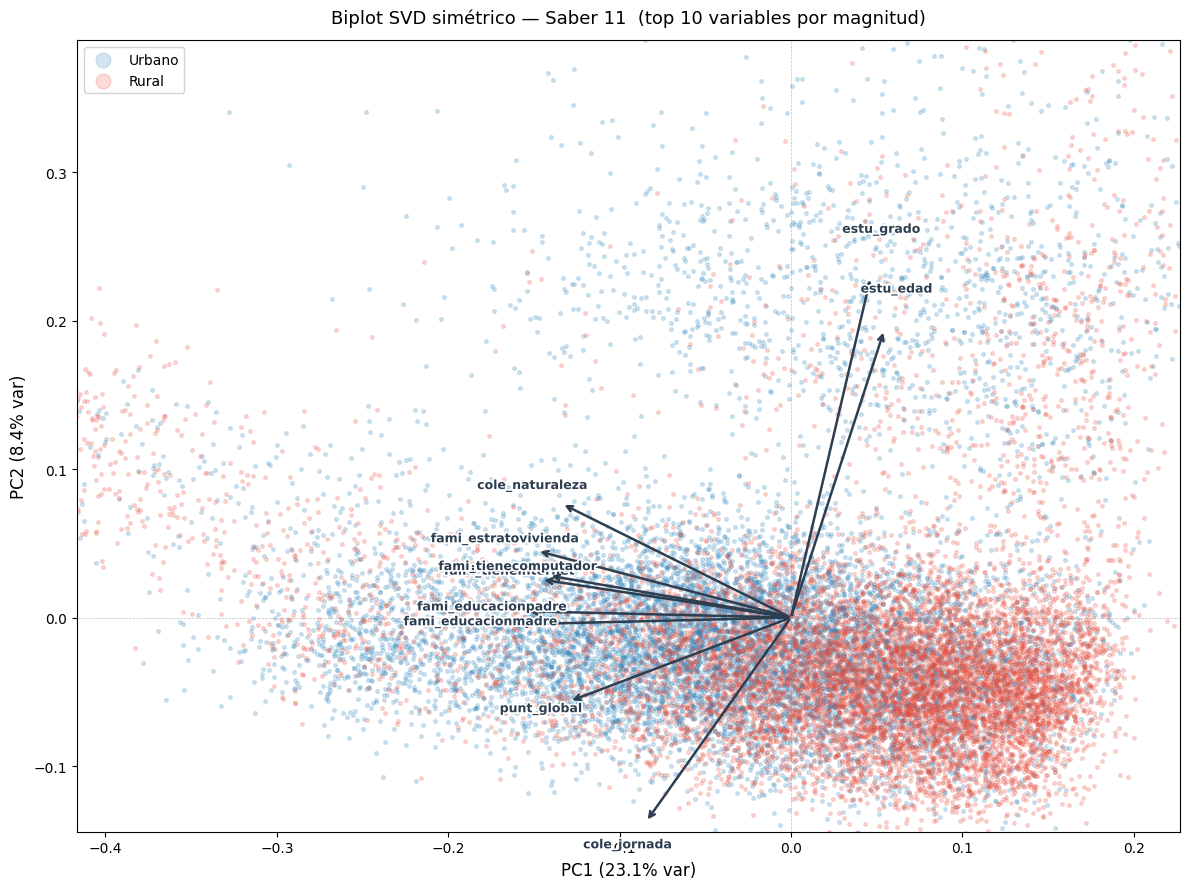

In [75]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

domain  = df_enc['cole_area_ubicacion'].to_numpy()
COLORS  = {'Urbano': '#2980b9', 'Rural': '#e74c3c'}
PC1_VAR = f"PC1 ({var_ratio[0]*100:.1f}% var)"
PC2_VAR = f"PC2 ({var_ratio[1]*100:.1f}% var)"

# Límites por percentil 1–99
p_lo, p_hi = 1, 99
xlim = np.percentile(G[:, 0], [p_lo, p_hi])
ylim = np.percentile(G[:, 1], [p_lo, p_hi])

# Factor de escala: flecha más larga = 40% del rango del eje X
h_max        = np.max(np.linalg.norm(H_plot, axis=1))
ARROW_SCALE  = ((xlim[1] - xlim[0]) * 0.4) / h_max if h_max > 0 else 1.0

fig, ax = plt.subplots(figsize=(12, 9))

# Puntos
for dom, color in COLORS.items():
    mask = domain == dom
    ax.scatter(G[mask, 0], G[mask, 1],
               c=color, alpha=0.2, s=7, label=dom, rasterized=True)

# Flechas — solo las top N
arrow_kw = dict(arrowstyle='->', color='#2c3e50', lw=1.8)
text_kw  = dict(fontsize=9, color='#2c3e50', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

for feat, (hx, hy) in zip(features_plot, H_plot * ARROW_SCALE):
    ax.annotate('', xy=(hx, hy), xytext=(0, 0), arrowprops=arrow_kw)
    ax.text(hx * 1.13, hy * 1.13, feat, ha='center', **text_kw)

# Ejes
margin_x = (xlim[1] - xlim[0]) * 0.05
margin_y = (ylim[1] - ylim[0]) * 0.05
ax.set_xlim(xlim[0] - margin_x, xlim[1] + margin_x)
ax.set_ylim(ylim[0] - margin_y, ylim[1] + margin_y)
ax.axhline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
ax.set_xlabel(PC1_VAR, fontsize=12)
ax.set_ylabel(PC2_VAR, fontsize=12)
ax.set_title(f'Biplot SVD simétrico — Saber 11  (top {TOP_N} variables por magnitud)',
             fontsize=13, pad=12)
ax.legend(markerscale=4, framealpha=0.85, fontsize=10)

plt.tight_layout()
plt.savefig('biplot_saber11.png', dpi=150, bbox_inches='tight')
plt.show()